In [ ]:
#list of available datasets with available control and perturbed data
#The following datasets make use of crispr screening such as ShRNA, CRISPRi, CRISPRa and CRISPRKO
#https://virtualcellchallenge.org/datasets and https://colab.research.google.com/drive/1QKOtYP7bMpdgDJEipDxaJqOchv7oQ-_l#scrollTo=wShYx6z-ajtN
#https://zenodo.org/records/15731884

#Cytokine Perturbations
#https://figshare.com/articles/dataset/pbmc_parse/28589774?file=53372768
#https://support.parsebiosciences.com/hc/en-us/articles/7704577188500-How-to-analyze-a-1-million-cell-data-set-using-Scanpy-and-Harmony

In [ ]:
#The following steps should be adjusted based on the dataset under consideration
# The insilico perturbation reinforcement learning environment can be modified to target specific gene(s) for the
#following datasets
#https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE134139
#https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE119352

In [ ]:
from zipfile import ZipFile
from tqdm.auto import tqdm
import os
%pip install requests tqdm
#This cell of code was adapted from the virtual cell challenge
#https://colab.research.google.com/drive/1QKOtYP7bMpdgDJEipDxaJqOchv7oQ-_l#scrollTo=wShYx6z-ajtN
import requests
from tqdm.auto import tqdm  # picks the best bar for the environment

website = "https://storage.googleapis.com/vcc_data_prod/datasets/state/competition_support_set.zip"
output_path = "competition_support_set.zip"


response = requests.get(website, stream=True)
total = int(response.headers.get("content-length", 0))

with open(output_path, "wb") as f, tqdm(
    total=total, unit='B', unit_scale=True, desc="Downloading"
) as bar:
    for chunk in response.iter_content(chunk_size=8192):
        if not chunk:
            break
        f.write(chunk)
        bar.update(len(chunk))
out_dir  = "competition_support_set"

os.makedirs(out_dir, exist_ok=True)

with ZipFile(output_path, 'r') as z:
    for member in tqdm(z.infolist(), desc="Unzipping", unit="file"):
        z.extract(member, out_dir)

Exception ignored in: <function _get_module_lock.<locals>.cb at 0x7c2aa91ba5c0>
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 454, in cb
KeyboardInterrupt: 
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen im

KeyboardInterrupt: 

In [ ]:
!7z x 1M_PBMC_T1D_Parse.zip -o1M_PBMC_T1D_Parse


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 3618245992 bytes (3451 MiB)

Extracting archive: 1M_PBMC_T1D_Parse.zip
--
Path = 1M_PBMC_T1D_Parse.zip
Type = zip
Physical Size = 3618245992

  0%      0% 1 - cell_metadata_1M_PBMC.csv                                    0% 2        0% 2 - DGE_1M_PBMC.mtx                          1% 2 - DGE_1M_PBMC.mtx                          2% 2 - DGE_1M_PBMC.mtx                          3% 2 - DGE_1M_PBMC.mtx                          4% 2 - DGE_1M_PBMC.mt

In [ ]:
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix

adata = sc.read_mtx("1M_PBMC_T1D_Parse/DGE_1M_PBMC.mtx").T

sc.pp.subsample(adata, n_obs=20_000, random_state=42)

sc.pp.filter_genes(adata, min_cells=10)

adata.X = adata.X.astype(np.float32)
adata.X = csr_matrix(adata.X)

adata.write(
    "PBMC_Parse_20k.h5ad",
    compression="gzip",
    compression_opts=9
)



In [ ]:
import scanpy as sc
import numpy as np

# ----------------------------
# CONFIG
# ----------------------------
INPUT_H5AD  = "competition_support_set/competition_support_set/competition_train.h5"
OUTPUT_H5AD = "train_20k.h5ad"
N_TARGET    = 20_000 # the target can be increase by  considering availability of RAM
SEED        = 42

np.random.seed(SEED)

# ----------------------------
# LOAD (disk-backed)
# ----------------------------
adata = sc.read_h5ad(INPUT_H5AD, backed="r")
print("Loaded (backed):", adata)

# ----------------------------
# RANDOM SAMPLE
# ----------------------------
n_obs = adata.n_obs

if N_TARGET >= n_obs:
    indices = np.arange(n_obs)
else:
    indices = np.random.choice(n_obs, size=N_TARGET, replace=False)

print("Selected cells:", len(indices))

# ----------------------------
# LOAD REDUCE DATA  INTO MEMORY
# ----------------------------
adata_reduce_small = adata[indices].to_memory()

print("Final dataset:", adata_reduce_small)
print("Obs columns:", list(adata_reduce_small.obs.columns))
print("Var columns:", list(adata_reduce_small.var.columns))

# ----------------------------
# SAVE
# ----------------------------
adata_reduce_small.write_h5ad(OUTPUT_H5AD)
print(f"Saved → {OUTPUT_H5AD}")


Loaded (backed): AnnData object with n_obs × n_vars = 221273 × 18080 backed at 'competition_support_set/competition_support_set/competition_train.h5'
    obs: 'target_gene', 'guide_id', 'batch', 'batch_var', 'cell_type'
    uns: 'log1p'
Selected cells: 20000
Final dataset: AnnData object with n_obs × n_vars = 20000 × 18080
    obs: 'target_gene', 'guide_id', 'batch', 'batch_var', 'cell_type'
    uns: 'log1p'
Obs columns: ['target_gene', 'guide_id', 'batch', 'batch_var', 'cell_type']
Var columns: []
Saved → train_20k.h5ad


In [5]:
#

# modify based on the selected dataset from the first cell

import scanpy as sc
# Virtual Cell Challenge Dataset
adata = sc.read_h5ad("train_20k.h5ad")
adata = adata.to_memory()

# Virtual Cell Challenge Dataset
control_mask = adata.obs["target_gene"] == "non-targeting"
perturb_mask = adata.obs["target_gene"] != "non-targeting"


# cytokine Dataset
#adata = sc.read_h5ad("cytokine_20k.h5ad")
#control_mask = adata.obs["treatment"] == "PBS"
#perturb_mask = adata.obs["treatment"] != "PBS"


adata_ctrl = adata[control_mask].copy()
adata_pert = adata[perturb_mask].copy()
#adata_ctrl
#adata_pert

# Clonal Aware Data(https://zenodo.org/records/15731884)
#adata_ctrl = sc.read_10x_h5("filtered_feature_bc_matrix_control1.h5")
#adata_pert = sc.read_10x_h5("filtered_feature_bc_matrix.h5")

adata_ctrl.var_names_make_unique()
adata_pert.var_names_make_unique()




import os
import numpy as np
import scipy.io as sio
from scipy import sparse

def export_to_mtx(adata, outdir):
    os.makedirs(outdir, exist_ok=True)

    # ---- Expression matrix (cells × genes → genes × cells for MTX) ----
    X = adata.X
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    sio.mmwrite(
        os.path.join(outdir, "matrix.mtx"),
        X.T  # MTX expects genes × cells
    )

    # ---- Gene names ----
    genes = adata.var_names.to_numpy()
    np.savetxt(
        os.path.join(outdir, "genes.tsv"),
        genes,
        fmt="%s"
    )

    # ---- Cell barcodes (recommended) ----
    barcodes = adata.obs_names.to_numpy()
    np.savetxt(
        os.path.join(outdir, "barcodes.tsv"),
        barcodes,
        fmt="%s"
    )

    print(f"Exported to {outdir}")
    print("  matrix.mtx (genes × cells)")
    print("  genes.tsv")
    print("  barcodes.tsv")

export_to_mtx(adata_ctrl, "Control_train Data")
#export_to_mtx(adata_pert, "Perturbed_validate Data")



Exported to Control_train Data
  matrix.mtx (genes × cells)
  genes.tsv
  barcodes.tsv


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using device: cpu


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


CTRL raw: (3297, 18080) PTPN2 raw: (12367, 18080)
Common genes: 18080


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== MEAN METRICS ===
                                  MSE      RMSE       MAE        R2   Pearson
System      Algorithm                                                        
CTRL-screen PPO (Test)       1.379832  1.155053  0.932203 -0.405688  0.337897
            TRPO→PPO (Test)  0.032678  0.167787  0.134378  0.966946  0.990635


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== PTPN2 WORLD MODEL METRICS ===
  System       Model  Split       MSE      RMSE       MAE        R2   Pearson
0  PTPN2  WorldModel   Test  0.111701  0.318316  0.196913  0.832000  0.917359
1  PTPN2  WorldModel  Train  0.052771  0.218392  0.151398  0.932647  0.967314

=== Trajectory similarity (mean) ===
                DTW  Wasserstein
CompareTo                       
CTRL-exp   1.402837     0.689189
PTPN2-exp  1.371920     0.670943


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


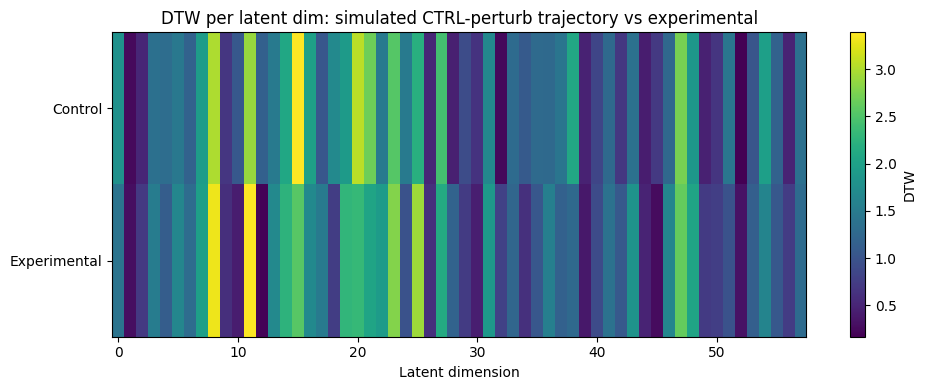


=== MEAN REGRESSION METRICS (TRAIN vs TEST) ===
             System Algorithm  Split       MSE      RMSE       MAE        R2  \
0  CTRL-gene-screen       PPO   Test  1.379832  1.155053  0.932203 -0.405688   
1  CTRL-gene-screen       PPO  Train  1.528449  1.207701  0.978795 -0.378410   
2  CTRL-gene-screen  TRPO→PPO   Test  0.032678  0.167787  0.134378  0.966946   
3  CTRL-gene-screen  TRPO→PPO  Train  0.036092  0.175727  0.142938  0.967238   

    Pearson  
0  0.337897  
1  0.370668  
2  0.990635  
3  0.991801  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


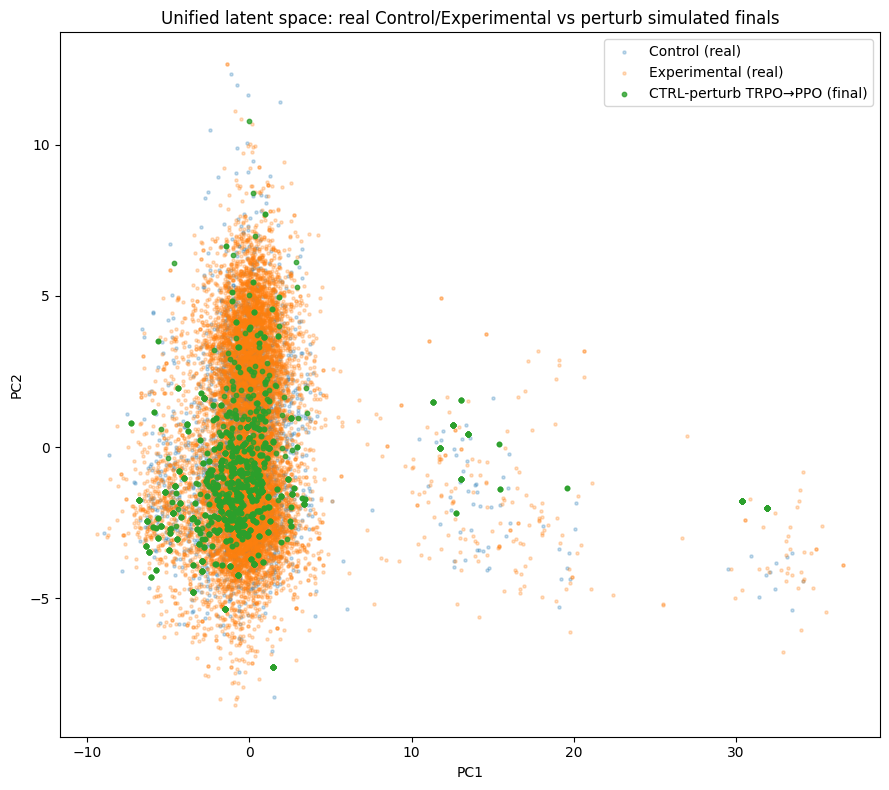

In [6]:
# ============================================================
# Unified CTRL(control) + PTPN2(perturbed) CRISPR RL (Model-based + Model-free)
# MULTI-GENE CRISPRi SCREENING VERSION
#
# Author: Boabang Francis et al. (Omics Codeathon)
#Part of the code was generated with Open AI chat GPT
#OpenAI. (2024). ChatGPT (GPT-4/GPT-5 family) [Large language model]. https://chat.openai.com/
# Encoder (leakage-safe):
#   - Align genes (CTRL, PTPN2)
#   - True 80/20 split on PTPN2 BEFORE preprocessing
#   - HVG on PTPN2-TRAIN only → apply to PTPN2-TEST + CTRL
#   - Gene Autoencoder on PTPN2-TRAIN only → gene-latent Z (cells × GENE_EMB_DIM)
#   - PCA on PTPN2-TRAIN only → apply to PTPN2-TEST + CTRL
#   - Simple inference-only GAT on joint PCA graph (no training labels)
#   - Fused embedding = [Z, PCA(Z), GAT(PCA(Z))]  (shared latent space)
#
# Multi-gene screening:
#   - Build gene_effects E ∈ R^{G×D} from CTRL data (PCA directions of genes in latent space)
#   - RL action a ∈ [-1,1]^G (gene repression strengths)
#   - Dynamics: x_{t+1} = x_t + scale * (a @ E)
#   - Reward: -||x-target||^2 - λ2||a||^2 - λ1||a||_1  (sparse screens)
# We extend the pipeline in
#Heydari T, A Langley M, Fisher CL, Aguilar-Hidalgo D, Shukla S, Yachie-Kinoshita A, Hughes M, M McNagny K, Zandstra PW. IQCELL:
# A platform for predicting the effect of gene perturbations on developmental trajectories using single-cell RNA-seq data.
# RL:
#   - CTRL: model-free multi-step gene-screen environment (learn sparse gene set)
#   - PTPN2: model-based world model fθ (optional; kept for evaluation parity)
#
# Evaluation:
#   - Single-dim regression metrics (MSE/RMSE/MAE/R2/Pearson) start→final
#   - IQCELL-style full H-step trajectories vs pseudotime-sorted experimental
#   - DTW + 1D Wasserstein per latent dimension
#   - Gene hit ranking from |action| statistics (Top-K hits)
# ============================================================

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import sparse
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
import math
import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad

import gymnasium as gym
from gymnasium import spaces

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn

from stable_baselines3 import PPO
from sb3_contrib import TRPO
from stable_baselines3.common.env_checker import check_env

# ----------------------------
# GLOBALS
# ----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 1) PATHS / HYPERPARAMETERS
# ============================================================

CTRL_MATRIX = "Control_train Data/matrix.mtx"
CTRL_FEAT   = "Control_train Data/genes.tsv"

PTPN2_MATRIX = "Perturbed_validate Data/matrix.mtx"
PTPN2_FEAT   = "Perturbed_validate Data/genes.tsv"


N_TOP_GENES   = 200 # use 200 for  replogle genome wide dataset % 100 for PBMC_cytokine dataset % 50 for the SMAD2 dataset

PERTURBATION_TYPE = "gene" # select either cytokine or gene depending on the perturbation type

GENE_EMB_DIM  = 16
N_PCS         = 10
GAT_OUT_DIM   = 32
AE_EPOCHS     = 100
BATCH_SIZE    = 64

# World model (optional but kept)
WORLD_HIDDEN  = 128
K_NEXT        = 5
WORLD_EPOCHS  = 100
WORLD_LR      = 1e-3

# RL
HORIZON       = 1
PPO_TIMESTEPS_BASELINE_ctrl = 150_000
TRPO_TIMESTEPS_STAGE1_ctrl  = 10_000
PPO_TIMESTEPS_STAGE2_ctrl   = 140_000

# Screening / env
ACTION_L2 = 0.01
ACTION_L1 = 0.05          # sparsity
ALPHA     = 1.0           # in-silico CTRL target = mu - ALPHA*std

# Rollouts / evaluation
ROLLOUT_SAMPLES = 1500
N_TRAJ_DTW      = 128

# ============================================================
# 2) LOAD MTX + ALIGN GENES
# ============================================================

def load_mtx(mtx_path, feat_path):
    X = sio.mmread(mtx_path)
    if not sparse.isspmatrix(X):
        X = sparse.coo_matrix(X)
    X = X.T.tocsr()  # cells x genes
    genes = pd.read_csv(feat_path, sep="\t", header=None).iloc[:, 0].astype(str).values
    return X, genes

ctrl_X_raw, ctrl_genes   = load_mtx(CTRL_MATRIX, CTRL_FEAT)
pt_X_raw,   pt_genes     = load_mtx(PTPN2_MATRIX, PTPN2_FEAT)

genes_common, idx_ctrl, idx_pt = np.intersect1d(ctrl_genes, pt_genes, return_indices=True)
ctrl_X_raw = ctrl_X_raw[:, idx_ctrl]
pt_X_raw   = pt_X_raw[:, idx_pt]

print("CTRL raw:", ctrl_X_raw.shape, "PTPN2 raw:", pt_X_raw.shape)
print("Common genes:", len(genes_common))

X_ctrl_all = ctrl_X_raw.toarray().astype(np.float32)
X_pt_all   = pt_X_raw.toarray().astype(np.float32)

# ============================================================
# 3) TRUE 80/20 PTPN2 SPLIT (BEFORE PREPROCESSING)
# ============================================================

X_pt_tr_raw, X_pt_te_raw = train_test_split(
    X_pt_all, test_size=0.20, random_state=SEED, shuffle=True
)
print("PTPN2 train raw:", X_pt_tr_raw.shape)
print("PTPN2 test raw:",  X_pt_te_raw.shape)

# ============================================================
# 4) HVG ON PTPN2 TRAIN ONLY → APPLY TO PTPN2 TEST + CTRL
# ============================================================

adata_pt_tr = ad.AnnData(X_pt_tr_raw)
adata_pt_tr.var_names = genes_common

sc.pp.normalize_total(adata_pt_tr, target_sum=1e4)
sc.pp.log1p(adata_pt_tr)
sc.pp.highly_variable_genes(adata_pt_tr, n_top_genes=N_TOP_GENES, subset=True)
sc.pp.scale(adata_pt_tr, max_value=10)

hvg_genes = adata_pt_tr.var_names.astype(str).values
hvg_mask  = np.isin(genes_common, hvg_genes)

def preprocess_to_hvg(X, genes_hvg):
    adata = ad.AnnData(X[:, hvg_mask])
    adata.var_names = genes_hvg
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)
    return adata

adata_pt_te = preprocess_to_hvg(X_pt_te_raw, hvg_genes)
adata_ctrl  = preprocess_to_hvg(X_ctrl_all,  hvg_genes)

X_pt_tr = adata_pt_tr.X.astype(np.float32)
X_pt_te = adata_pt_te.X.astype(np.float32)
X_ctrl  = adata_ctrl.X.astype(np.float32)

print("PTPN2 train HVG:", X_pt_tr.shape)
print("PTPN2 test  HVG:", X_pt_te.shape)
print("CTRL   HVG:",      X_ctrl.shape)

# ============================================================
# 5) GENE AUTOENCODER (PTPN2 TRAIN ONLY) → Z
# ============================================================

class GeneAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, in_dim)
        )
    def encode(self, x): return self.encoder(x)
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

ae = GeneAutoencoder(X_pt_tr.shape[1], GENE_EMB_DIM).to(DEVICE)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

Xt = torch.tensor(X_pt_tr, dtype=torch.float32, device=DEVICE)
ae.train()
for epoch in range(AE_EPOCHS):
    perm = torch.randperm(Xt.shape[0], device=DEVICE)
    total = 0.0
    for i in range(0, Xt.shape[0], BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        batch = Xt[idx]
        opt.zero_grad()
        recon, _ = ae(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        opt.step()
        total += loss.item() * batch.size(0)
    if (epoch+1) % 10 == 0:
        print(f"[AE] {epoch+1:03d}/{AE_EPOCHS} loss={total/Xt.shape[0]:.4f}")

ae.eval()
with torch.no_grad():
    Z_pt_tr = ae.encode(torch.tensor(X_pt_tr, device=DEVICE)).cpu().numpy()
    Z_pt_te = ae.encode(torch.tensor(X_pt_te, device=DEVICE)).cpu().numpy()
    Z_ctrl  = ae.encode(torch.tensor(X_ctrl,  device=DEVICE)).cpu().numpy()

print("Z PTPN2 train:", Z_pt_tr.shape, "Z PTPN2 test:", Z_pt_te.shape, "Z CTRL:", Z_ctrl.shape)

# ============================================================
# 6) PCA (fit on PTPN2 train only) → transform others
# ============================================================

pca = PCA(n_components=N_PCS, random_state=SEED)
P_pt_tr = pca.fit_transform(Z_pt_tr)
P_pt_te = pca.transform(Z_pt_te)
P_ctrl  = pca.transform(Z_ctrl)

# ============================================================
# 7) SIMPLE INFERENCE-ONLY GAT ON JOINT PCA GRAPH
# ============================================================

class SimpleGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, neighbor_lists, alpha=0.2):
        super().__init__()
        self.neighbors = neighbor_lists
        self.W = nn.Parameter(torch.empty(in_dim, out_dim))
        self.a = nn.Parameter(torch.empty(2*out_dim, 1))
        self.leaky = nn.LeakyReLU(alpha)
        nn.init.xavier_uniform_(self.W)
        nn.init.xavier_uniform_(self.a)

    def forward(self, X):
        Wh = X @ self.W
        out = torch.zeros_like(Wh)
        for i in range(Wh.shape[0]):
            neigh = self.neighbors[i]
            h_i = Wh[i]
            h_j = Wh[neigh]
            k = len(neigh)
            a_in = torch.cat([h_i.expand(k, -1), h_j], dim=1)
            e = self.leaky(a_in @ self.a).squeeze(-1)
            alpha = torch.softmax(e, dim=0)
            out[i] = (alpha.unsqueeze(1) * h_j).sum(0)
        return out

# Build graph on ALL PCA points (train + test + ctrl)
P_full = np.vstack([P_pt_tr, P_pt_te, P_ctrl])
n_tr, n_te, n_ctrl = P_pt_tr.shape[0], P_pt_te.shape[0], P_ctrl.shape[0]

adata_graph = ad.AnnData(P_full)
adata_graph.obsm["X_pca"] = P_full
sc.pp.neighbors(adata_graph, n_neighbors=15, use_rep="X_pca")
A = adata_graph.obsp["connectivities"].tocsr()

neighbor_lists = []
for i in range(A.shape[0]):
    neigh = A[i].indices
    if i not in neigh:
        neigh = np.append(neigh, i)
    neighbor_lists.append(neigh)

gat = SimpleGATLayer(N_PCS, GAT_OUT_DIM, neighbor_lists).to(DEVICE)
with torch.no_grad():
    G_full = gat(torch.tensor(P_full, dtype=torch.float32, device=DEVICE)).cpu().numpy()

G_pt_tr = G_full[:n_tr]
G_pt_te = G_full[n_tr:n_tr+n_te]
G_ctrl  = G_full[n_tr+n_te:]

# ============================================================
# 8) FUSED EMBEDDINGS (shared latent space)
# ============================================================

emb_pt_tr = np.concatenate([Z_pt_tr, P_pt_tr, G_pt_tr], axis=1).astype(np.float32)
emb_pt_te = np.concatenate([Z_pt_te, P_pt_te, G_pt_te], axis=1).astype(np.float32)
emb_ctrl  = np.concatenate([Z_ctrl,  P_ctrl,  G_ctrl],  axis=1).astype(np.float32)
emb_pt_all = np.vstack([emb_pt_tr, emb_pt_te]).astype(np.float32)

print("Fused PTPN2 train:", emb_pt_tr.shape)
print("Fused PTPN2 test :", emb_pt_te.shape)
print("Fused CTRL      :", emb_ctrl.shape)

# ============================================================
# 9) PSEUDOTIME (PTPN2 TRAIN) + MAP TO CTRL & PTPN2 TEST
# ============================================================

# DPT on PTPN2 TRAIN using HVG expression (leakage-safe)
sc.pp.neighbors(adata_pt_tr, n_neighbors=15, use_rep=None)
sc.tl.diffmap(adata_pt_tr)
adata_pt_tr.uns["iroot"] = len(adata_pt_tr) // 2
sc.tl.dpt(adata_pt_tr)
pt_pt_tr = adata_pt_tr.obs["dpt_pseudotime"].values.astype(float)

def map_to_pseudotime(ref_emb, ref_pt, X):
    d = cdist(X, ref_emb)
    nn = d.argmin(axis=1)
    return ref_pt[nn]

pt_pt_te = map_to_pseudotime(emb_pt_tr, pt_pt_tr, emb_pt_te)
pt_ctrl  = map_to_pseudotime(emb_pt_tr, pt_pt_tr, emb_ctrl)

def clean_pseudotime(pt):
    pt = np.array(pt, dtype=float)
    mask = np.isfinite(pt)
    if mask.sum() == 0:
        raise ValueError("All pseudotime invalid!")
    pt[~mask] = np.nanmean(pt[mask])
    return pt

pt_pt_tr = clean_pseudotime(pt_pt_tr)
pt_pt_te = clean_pseudotime(pt_pt_te)
pt_ctrl  = clean_pseudotime(pt_ctrl)
pt_pt_all = np.concatenate([pt_pt_tr, pt_pt_te], axis=0)

# ============================================================
# 10) OPTIONAL: WORLD MODEL fθ ON PTPN2 (kept for parity)
# ============================================================

def build_world_pairs(emb, pt, k=5, min_delta=1e-4):
    Xc, Xn = [], []
    for i in range(len(emb)):
        mask = pt > pt[i] + min_delta
        cand = np.where(mask)[0]
        if len(cand) < k:
            continue
        dists = np.linalg.norm(emb[cand] - emb[i], axis=1)
        nn = cand[np.argsort(dists)[:k]]
        Xc.append(emb[i])
        Xn.append(emb[nn].mean(axis=0))
    return np.vstack(Xc), np.vstack(Xn)

Xc_wm, Xn_wm = build_world_pairs(emb_pt_tr, pt_pt_tr, k=K_NEXT)
print("World pairs:", Xc_wm.shape, Xn_wm.shape)

class WorldModel(nn.Module):
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, dim)
        )
    def forward(self, x): return self.net(x)

world_model = WorldModel(emb_pt_tr.shape[1], WORLD_HIDDEN).to(DEVICE)
wopt = torch.optim.Adam(world_model.parameters(), lr=WORLD_LR)
wmse = nn.MSELoss()

Xc_t = torch.tensor(Xc_wm, dtype=torch.float32, device=DEVICE)
Xn_t = torch.tensor(Xn_wm, dtype=torch.float32, device=DEVICE)

world_model.train()
for epoch in range(WORLD_EPOCHS):
    perm = torch.randperm(Xc_t.shape[0], device=DEVICE)
    total = 0.0
    for i in range(0, Xc_t.shape[0], BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        bC = Xc_t[idx]
        bN = Xn_t[idx]
        wopt.zero_grad()
        pred = world_model(bC)
        loss = wmse(pred, bN)
        loss.backward()
        wopt.step()
        total += loss.item() * bC.size(0)
    if (epoch+1) % 10 == 0:
        print(f"[WORLD] {epoch+1:03d}/{WORLD_EPOCHS} loss={total/Xc_t.shape[0]:.4f}")

world_model.eval()

# ============================================================
# 11) TARGETS + CTRL SPLIT
# ============================================================

target_pt_real = emb_pt_tr.mean(axis=0).astype(np.float32)

emb_ctrl_tr, emb_ctrl_te, pt_ctrl_tr, pt_ctrl_te = train_test_split(
    emb_ctrl, pt_ctrl, test_size=0.2, random_state=SEED, shuffle=True
)

mu_ctrl = emb_ctrl_tr.mean(axis=0)
sd_ctrl = emb_ctrl_tr.std(axis=0) + 1e-8
target_ctrl_insilico = (mu_ctrl - ALPHA * sd_ctrl).astype(np.float32)

print("Targets:", target_ctrl_insilico.shape, target_pt_real.shape)

# ============================================================
# 12) BUILD GENE EFFECTS MATRIX E (G × D) FOR MULTI-GENE SCREEN
# ============================================================
# We need a mapping from gene repression to latent movement.
# Here: use CTRL data gene expression (HVG space) and latent emb (fused)
# Fit a simple linear model per gene: delta_x ≈ (gene_expr centered) * v_g
# Practically: use correlation between gene expression and each latent dim:
#   E[g, d] = corr(gene_expr, emb_dim)
#
# This yields E ∈ R^{G×D}, where G = #HVG genes.

def build_gene_effects_corr(X_expr_ctrl, emb_ctrl, gene_names):
    """
    X_expr_ctrl: (n_cells, G) CTRL HVG expression after preprocessing (adata_ctrl.X)
    emb_ctrl:    (n_cells, D) CTRL fused embedding
    returns:
        E: (G, D) gene effects
    """
    X = np.asarray(X_expr_ctrl, dtype=np.float32)
    Y = np.asarray(emb_ctrl, dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)
    Y = (Y - Y.mean(axis=0, keepdims=True)) / (Y.std(axis=0, keepdims=True) + 1e-8)
    # corr = (X^T Y) / (n-1)
    E = (X.T @ Y) / max(1, (X.shape[0] - 1))
    E = np.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    # normalize each gene vector for comparable action scaling
    norms = np.linalg.norm(E, axis=1, keepdims=True) + 1e-8
    E = E / norms
    return E

gene_names = hvg_genes.astype(str).tolist()  # these are the "screened" genes
gene_effects = build_gene_effects_corr(adata_ctrl.X, emb_ctrl, gene_names)

#print("Gene effects:", gene_effects.shape, " (#genes × latent_dim)")



# Cytokines

#def build_cytokine_effects(emb_ctrl, cytokine_labels):
 #   cytokines = np.unique(cytokine_labels)
 #   D = emb_ctrl.shape[1]
#    E = np.zeros((len(cytokines), D), dtype=np.float32)

#    base = emb_ctrl.mean(axis=0)

#    for i, ck in enumerate(cytokines):
 #       mask = cytokine_labels == ck
 #       if mask.sum() < 10:
 #           continue
#        E[i] = emb_ctrl[mask].mean(axis=0) - base

#    E /= (np.linalg.norm(E, axis=1, keepdims=True) + 1e-8)
 #   return E, cytokines


#adata_pt = adata_pt_tr.concatenate(adata_pt_te)
#cytokine_labels = adata_pt.obs["treatment"].astype(str).values
#emb_pt_all = np.vstack([emb_pt_tr, emb_pt_te])
#emb_pt_all.shape[0] == len(cytokine_labels)
#E_cyt, cytokine_names = build_cytokine_effects(
#    emb_ctrl=emb_pt_all,          # embeddings of cytokine-treated cells
#    cytokine_labels=cytokine_labels
#)

#cytokine_effects = E_cyt


# cytokines Environment


class CytokineCtrlEnv(gym.Env):
    """
    Model-free cytokine screening on CTRL.

    State:  x ∈ R^D  (fused latent)
    Action: c ∈ [-1,1]^C (cytokine dosages)
    Dyn:    x' = x + scale*(c @ E_cyt)
    Reward: -||x-target||^2 - λ2||c||^2
    """
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        ctrl_emb,
        pseudotime,
        cytokine_effects,
        target,
        scale=0.3,
        horizon=6,
        action_l2=0.01,
    ):
        super().__init__()
        self.ctrl = np.asarray(ctrl_emb, dtype=np.float32)
        self.pt = np.asarray(pseudotime, dtype=float)
        self.E = np.asarray(cytokine_effects, dtype=np.float32)  # (C,D)
        self.target = np.asarray(target, dtype=np.float32)

        self.n_cells, self.D = self.ctrl.shape
        self.C = self.E.shape[0]

        self.scale = float(scale)
        self.horizon = int(horizon)
        self.l2 = float(action_l2)

        self.action_space = spaces.Box(-1.0, 1.0, (self.C,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, (self.D,), dtype=np.float32)

        self.state = None
        self.t = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        probs = self.pt.copy()
        probs[~np.isfinite(probs)] = 0.0
        probs += 1e-6
        probs /= probs.sum()

        idx = np.random.choice(self.n_cells, p=probs)
        self.state = self.ctrl[idx].copy()
        self.t = 0
        return self.state, {}

    def step(self, action):
        c = np.asarray(action, dtype=np.float32)
        c = np.clip(c, -1.0, 1.0)

        delta = c @ self.E          # (D,)
        nxt = self.state + self.scale * delta

        diff = nxt - self.target
        reward = -float(
            np.dot(diff, diff) + self.l2 * np.dot(c, c)
        )

        if not np.isfinite(reward):
            reward = -1e6

        self.state = nxt
        self.t += 1
        done = self.t >= self.horizon
        return nxt, reward, done, False, {}







# ============================================================
# 13) MULTI-GENE SCREENING ENV (CTRL model-free)
# ============================================================

class CRISPRiCtrlGeneScreenEnv(gym.Env):
    """
    Model-free multi-gene CRISPRi screening on CTRL.

    State:  x ∈ R^D  (fused latent)
    Action: a ∈ [-1,1]^G (gene repression)
    Dyn:    x' = x + scale*(a @ E)
    Reward: -||x-target||^2 - λ2||a||^2 - λ1||a||_1
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, ctrl_emb, pseudotime, gene_effects, target,
                 scale=0.3, horizon=12, action_l2=0.01, action_l1=0.0):
        super().__init__()
        self.ctrl = np.asarray(ctrl_emb, dtype=np.float32)
        self.pt = np.asarray(pseudotime, dtype=float)
        self.E = np.asarray(gene_effects, dtype=np.float32)  # (G,D)
        self.target = np.asarray(target, dtype=np.float32)

        assert self.ctrl.ndim == 2
        assert self.E.ndim == 2
        assert self.ctrl.shape[1] == self.E.shape[1] == self.target.shape[0]

        self.n_cells, self.D = self.ctrl.shape
        self.G = self.E.shape[0]
        self.scale = float(scale)
        self.horizon = int(horizon)
        self.l2 = float(action_l2)
        self.l1 = float(action_l1)

        self.action_space = spaces.Box(-1.0, 1.0, (self.G,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, (self.D,), dtype=np.float32)

        self.state = None
        self.t = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        probs = self.pt.copy()
        probs[~np.isfinite(probs)] = 0.0
        probs += 1e-6
        s = probs.sum()
        probs = (probs / s) if (s > 0 and np.isfinite(s)) else np.ones_like(probs) / len(probs)
        idx = np.random.choice(self.n_cells, p=probs)
        self.state = self.ctrl[idx].copy()
        self.t = 0
        return self.state, {}

    def step(self, action):
        a = np.asarray(action, dtype=np.float32)
        a = np.clip(a, -1.0, 1.0)

        delta = a @ self.E     # (D,)
        nxt = self.state + self.scale * delta

        diff = nxt - self.target
        reward = -float(
            np.dot(diff, diff)
            + self.l2 * np.dot(a, a)
            + self.l1 * np.sum(np.abs(a))
        )
        if not np.isfinite(reward):
            reward = -1e6

        self.state = nxt
        self.t += 1
        done = self.t >= self.horizon
        return nxt, reward, done, False, {}

# We’ll auto-match scale to typical world-model step (optional)
def estimate_world_step(world_model, emb, n_samples=300):
    idx = np.random.choice(emb.shape[0], size=n_samples, replace=True)
    xs = emb[idx]
    diffs = []
    with torch.no_grad():
        for x in xs:
            s = torch.tensor(x, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            nx = world_model(s).cpu().numpy()[0]
            diffs.append(np.linalg.norm(nx - x))
    return float(np.mean(diffs))

def compute_action_scale_for_gene_env(world_model, emb_pt_tr, D_lat):
    delta = estimate_world_step(world_model, emb_pt_tr)
    expected_norm = math.sqrt(D_lat / 3)  # random in [-1,1]^D
    return float(delta / (expected_norm + 1e-8))

ACTION_SCALE = compute_action_scale_for_gene_env(world_model, emb_pt_tr, emb_ctrl.shape[1])
print("ACTION_SCALE:", ACTION_SCALE)

if PERTURBATION_TYPE == "gene":
  env_ctrl_train = CRISPRiCtrlGeneScreenEnv(
        ctrl_emb=emb_ctrl_tr,
        pseudotime=pt_ctrl_tr,
        gene_effects=gene_effects,
        target=target_ctrl_insilico,
        scale=ACTION_SCALE,
        horizon=HORIZON,
        action_l2=ACTION_L2,
        action_l1=ACTION_L1,
    )
  env_ctrl_test = CRISPRiCtrlGeneScreenEnv(
        ctrl_emb=emb_ctrl_te,
        pseudotime=pt_ctrl_te,
        gene_effects=gene_effects,
        target=target_pt_real,          # test toward real PTPN2 mean
        scale=ACTION_SCALE,
        horizon=HORIZON,
        action_l2=ACTION_L2,
        action_l1=ACTION_L1,
    )

if PERTURBATION_TYPE == "cytokine":
  env_ctrl_train = CytokineCtrlEnv(
        ctrl_emb=emb_ctrl_tr,
        pseudotime=pt_ctrl_tr,
        cytokine_effects=gene_effects,
        target=target_ctrl_insilico,
        scale=ACTION_SCALE,
        horizon=HORIZON,
        action_l2=ACTION_L2,
    )
  env_ctrl_test =CytokineCtrlEnv(
        ctrl_emb=emb_ctrl_te,
        pseudotime=pt_ctrl_te,
        cytokine_effects=gene_effects,
        target=target_pt_real,
        scale=ACTION_SCALE,
        horizon=HORIZON,
        action_l2=ACTION_L2,
    )

check_env(env_ctrl_train)

# ============================================================
# 14) TRPO → PPO TRAINING (CTRL gene screening)
# ============================================================

def estimate_trpo_kl(trpo_model):
    try:
        return float(trpo_model.logger.name_to_value["train/approx_kl"])
    except Exception:
        return 0.01

ppo_ctrl = PPO("MlpPolicy", env_ctrl_train, verbose=1)
ppo_ctrl.learn(PPO_TIMESTEPS_BASELINE_ctrl)

trpo_ctrl = TRPO("MlpPolicy", env_ctrl_train, verbose=1)
trpo_ctrl.learn(TRPO_TIMESTEPS_STAGE1_ctrl)

kl = estimate_trpo_kl(trpo_ctrl)

ppo_ctrl_ms = PPO(
    "MlpPolicy",
    env_ctrl_train,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    gae_lambda=0.95,
    gamma=0.99,
    clip_range=0.2,
    target_kl=kl * 1.5,
)
ppo_ctrl_ms.policy.load_state_dict(trpo_ctrl.policy.state_dict())
ppo_ctrl_ms.learn(PPO_TIMESTEPS_STAGE2_ctrl)

# ============================================================
# 15) ROLLOUTS (start vs final) + GENE HIT EXTRACTION
# ============================================================

def rollout_last_with_actions(agent, env, n_samples=500):
    starts, finals, rewards, actions = [], [], [], []
    for _ in range(n_samples):
        obs, _ = env.reset()
        start = obs.copy()
        tot = 0.0
        for _ in range(env.horizon):
            a, _ = agent.predict(obs, deterministic=True)
            obs, r, done, _, _ = env.step(a)
            actions.append(a.copy())
            tot += r
            if done:
                break
        starts.append(start)
        finals.append(obs.copy())
        rewards.append(tot)
    return np.vstack(starts), np.vstack(finals), np.array(rewards), np.array(actions)

raw_ppo_te,  fin_ppo_te,  rew_ppo_te,  act_ppo_te  = rollout_last_with_actions(ppo_ctrl,    env_ctrl_test, ROLLOUT_SAMPLES)
raw_ms_te,   fin_ms_te,   rew_ms_te,   act_ms_te   = rollout_last_with_actions(ppo_ctrl_ms, env_ctrl_test, ROLLOUT_SAMPLES)

# Gene ranking by mean |action|
def rank_genes(actions, gene_names, topk=25):
    score = np.mean(np.abs(actions), axis=0)
    order = np.argsort(-score)
    rows = [{"rank": r+1, "gene": gene_names[i], "score": float(score[i])} for r,i in enumerate(order[:topk])]
    return pd.DataFrame(rows), score, order

top_df, gene_score, gene_order = rank_genes(act_ms_te, gene_names, topk=30)
top_df.to_csv("ctrl_gene_screen_top_hits_trpo_to_ppo.csv", index=False)
print("\nTop gene hits (TRPO→PPO, TEST):")
print(top_df.head(15))


# ============================================================
# 15b) TRAIN ROLLOUTS (for regression metrics)
# ============================================================

raw_ppo_tr, fin_ppo_tr, rew_ppo_tr, _ = rollout_last_with_actions(
    ppo_ctrl, env_ctrl_train, ROLLOUT_SAMPLES
)

raw_ms_tr, fin_ms_tr, rew_ms_tr, _ = rollout_last_with_actions(
    ppo_ctrl_ms, env_ctrl_train, ROLLOUT_SAMPLES
)






# ============================================================
# 16) METRICS (PER DIM + MEAN) start→final
# ============================================================

def metrics_1d(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    if np.std(y_true) == 0:
        pear = 0.0
    else:
        pear = float(np.corrcoef(y_true, y_pred)[0, 1])
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "Pearson": pear}

def eval_model(raw, fin, algo, system):
    rows = []
    D = raw.shape[1]
    for d in range(D):
        m = metrics_1d(raw[:, d], fin[:, d])
        m.update({"Dim": d, "Algorithm": algo, "System": system})
        rows.append(m)
    return pd.DataFrame(rows)

df_dim = pd.concat([
    eval_model(raw_ppo_te, fin_ppo_te, "PPO (Test)", "CTRL-screen"),
    eval_model(raw_ms_te,  fin_ms_te,  "TRPO→PPO (Test)", "CTRL-screen"),
], axis=0)

df_dim.to_csv("ctrl_gene_screen_single_dim_metrics.csv", index=False)
metric_cols = ["MSE","RMSE","MAE","R2","Pearson"]
df_mean = df_dim.groupby(["System","Algorithm"])[metric_cols].mean()
df_mean.to_csv("ctrl_gene_screen_mean_metrics.csv")
print("\n=== MEAN METRICS ===")
print(df_mean)


# ============================================================
# 16b) REGRESSION METRICS — TRAIN vs TEST
# ============================================================

def metrics_1d(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    pear = 0.0 if np.std(y_true) == 0 else float(np.corrcoef(y_true, y_pred)[0, 1])
    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pear,
    }

def eval_regression(raw, fin, algo, split):
    rows = []
    D = raw.shape[1]
    for d in range(D):
        m = metrics_1d(raw[:, d], fin[:, d])
        m.update({
            "Dim": d,
            "Algorithm": algo,
            "Split": split,
            "System": "CTRL-gene-screen",
        })
        rows.append(m)
    return pd.DataFrame(rows)




# ============================================================
# 10b) PTPN2 WORLD MODEL PREDICTION METRICS
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    pearson = 0.0 if np.std(y_true) == 0 else float(np.corrcoef(y_true, y_pred)[0,1])
    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson
    }

# ---- Predict next-state on TRAIN pairs ----
with torch.no_grad():
    pred_tr = world_model(Xc_t).cpu().numpy()
    true_tr = Xn_t.cpu().numpy()

# ---- Predict next-state on TEST (holdout PTPN2) ----
Xc_te, Xn_te = build_world_pairs(emb_pt_te, pt_pt_te, k=K_NEXT)

Xc_te_t = torch.tensor(Xc_te, dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    pred_te = world_model(Xc_te_t).cpu().numpy()

# ---- Per-dimension metrics ----
rows = []
for split, Y_true, Y_pred in [
    ("Train", true_tr, pred_tr),
    ("Test",  Xn_te,   pred_te),
]:
    for d in range(Y_true.shape[1]):
        m = regression_metrics(Y_true[:, d], Y_pred[:, d])
        m.update({
            "Dim": d,
            "Split": split,
            "System": "PTPN2",
            "Model": "WorldModel"
        })
        rows.append(m)

df_ptpn2_world = pd.DataFrame(rows)
df_ptpn2_world.to_csv("ptpn2_world_model_metrics_per_dim.csv", index=False)

# ---- Mean metrics ----
df_ptpn2_world_mean = (
    df_ptpn2_world
    .groupby(["System","Model","Split"])[["MSE","RMSE","MAE","R2","Pearson"]]
    .mean()
    .reset_index()
)

df_ptpn2_world_mean.to_csv("ptpn2_world_model_metrics_mean.csv", index=False)

print("\n=== PTPN2 WORLD MODEL METRICS ===")
print(df_ptpn2_world_mean)










# ============================================================
# 17) IQCELL-STYLE FULL TRAJECTORIES + DTW/OT
# ============================================================

def rollout_trajectories(agent, env, n_traj):
    trajs = []
    for _ in range(n_traj):
        obs, _ = env.reset()
        traj = [obs.copy()]
        for _ in range(env.horizon):
            a, _ = agent.predict(obs, deterministic=True)
            obs, r, done, _, _ = env.step(a)
            traj.append(obs.copy())
            if done:
                break
        if len(traj) < env.horizon + 1:
            last = traj[-1].copy()
            while len(traj) < env.horizon + 1:
                traj.append(last.copy())
        trajs.append(np.stack(traj, axis=0))
    return np.stack(trajs, axis=0)

traj_ms_te = rollout_trajectories(ppo_ctrl_ms, env_ctrl_test, N_TRAJ_DTW)  # (N,T,D)
traj_ms_mean = traj_ms_te.mean(axis=0)  # (T,D)

# Build experimental trajectories by pseudotime sorting
def build_exp_trajectory(emb, pt, n_points):
    order = np.argsort(pt)
    emb_sorted = emb[order]
    idx = np.linspace(0, emb_sorted.shape[0]-1, n_points).astype(int)
    return emb_sorted[idx]

T = HORIZON + 1
exp_ctrl = build_exp_trajectory(emb_ctrl, pt_ctrl, T)
exp_pt   = build_exp_trajectory(emb_pt_all, pt_pt_all, T)

def dtw_distance_1d(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    n, m = len(x), len(y)
    D = np.full((n+1, m+1), np.inf)
    D[0,0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(x[i-1] - y[j-1])
            D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return float(D[n,m])

# Compare simulated CTRL-screen traj to experimental CTRL and PTPN2
results = []
for label, exp in [("CTRL-exp", exp_ctrl), ("PTPN2-exp", exp_pt)]:
    for d in range(traj_ms_mean.shape[1]):
        sim_seq = traj_ms_mean[:, d]
        exp_seq = exp[:, d]
        results.append({
            "CompareTo": label,
            "Dim": d,
            "DTW": dtw_distance_1d(sim_seq, exp_seq),
            "Wasserstein": float(wasserstein_distance(sim_seq, exp_seq))
        })

df_traj = pd.DataFrame(results)
df_traj.to_csv("ctrl_gene_screen_traj_similarity_dtw_wasserstein.csv", index=False)

print("\n=== Trajectory similarity (mean) ===")
print(df_traj.groupby("CompareTo")[["DTW","Wasserstein"]].mean())







# DTW heatmap (CTRL vs PTPN2)
dtw_ctrl = df_traj[df_traj["CompareTo"]=="CTRL-exp"].sort_values("Dim")["DTW"].values
dtw_pt   = df_traj[df_traj["CompareTo"]=="PTPN2-exp"].sort_values("Dim")["DTW"].values
Dmin = min(len(dtw_ctrl), len(dtw_pt))
mat = np.vstack([dtw_ctrl[:Dmin], dtw_pt[:Dmin]])

plt.figure(figsize=(10,4))
plt.imshow(mat, aspect="auto")
plt.yticks([0,1], ["Control", "Experimental"])
plt.xlabel("Latent dimension")
plt.colorbar(label="DTW")
plt.title("DTW per latent dim: simulated CTRL-perturb trajectory vs experimental")
plt.tight_layout()
plt.show()


df_reg = pd.concat([
    # ---------- PPO ----------
    eval_regression(raw_ppo_tr, fin_ppo_tr, "PPO",        "Train"),
    eval_regression(raw_ppo_te, fin_ppo_te, "PPO",        "Test"),

    # ---------- TRPO → PPO ----------
    eval_regression(raw_ms_tr,  fin_ms_tr,  "TRPO→PPO",   "Train"),
    eval_regression(raw_ms_te,  fin_ms_te,  "TRPO→PPO",   "Test"),
], axis=0)

df_reg.to_csv("ctrl_perturb_regression_metrics_per_dim.csv", index=False)

metric_cols = ["MSE", "RMSE", "MAE", "R2", "Pearson"]

df_reg_mean = (
    df_reg
    .groupby(["System", "Algorithm", "Split"])[metric_cols]
    .mean()
    .reset_index()
)

df_reg_mean.to_csv("ctrl_perturb_regression_metrics_mean.csv", index=False)

print("\n=== MEAN REGRESSION METRICS (TRAIN vs TEST) ===")
print(df_reg_mean)



# ============================================================
# 18) 2D VISUALIZATION: REAL CTRL/PTPN2 + SIMULATED FINAL STATES
# ============================================================

X_vis = np.vstack([emb_ctrl, emb_pt_all, fin_ms_te])
vis_pca = PCA(n_components=2, random_state=SEED)
X2 = vis_pca.fit_transform(X_vis)

nA = emb_ctrl.shape[0]
nB = emb_pt_all.shape[0]
idx_ctrl = np.arange(0, nA)
idx_pt   = np.arange(nA, nA+nB)
idx_sim  = np.arange(nA+nB, nA+nB+fin_ms_te.shape[0])

plt.figure(figsize=(9,8))
plt.scatter(X2[idx_ctrl,0], X2[idx_ctrl,1], s=5, alpha=0.25, label="Control (real)")
plt.scatter(X2[idx_pt,0],   X2[idx_pt,1],   s=5, alpha=0.25, label="Experimental (real)")
plt.scatter(X2[idx_sim,0],  X2[idx_sim,1],  s=10, alpha=0.8, label="CTRL-perturb TRPO→PPO (final)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Unified latent space: real Control/Experimental vs perturb simulated finals")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
import zipfile
from google.colab import files

zip_name = "cyokines_all_files.zip"
root_dir = "/content"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for foldername, subfolders, filenames in os.walk(root_dir):
        for filename in filenames:
            file_path = os.path.join(foldername, filename)
            arcname = os.path.relpath(file_path, root_dir)
            zipf.write(file_path, arcname)

files.download(zip_name)




OSError: [Errno 28] No space left on device

In [3]:
pip install sb3_contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 3.2 MB/s eta 0:00:00
